In [82]:
import torch
from torch import nn
from datasets import Dataset
from torch.utils.data import DataLoader
from transformers import PreTrainedTokenizerBase, AutoModelForSequenceClassification


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from typing import Dict, List, Tuple
from pathlib import Path
from tqdm.auto import tqdm
from timeit import default_timer as timer

In [62]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
file_path = Path("../data/Womens Clothing E-Commerce Reviews.csv")

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
df = df.dropna(subset=['Review Text'])


train_dataset, test_dataset = train_test_split(df, test_size=0.2, random_state=42)

In [37]:
def create_dataloaders(
    train_dataset,
    test_dataset,
    tokenizer: PreTrainedTokenizerBase,
    batch_size: int,
    max_length: int = 256,
    test_size: float = 0.15,
    random_state: int = 42
):
    """Creates training and validation DataLoaders for text classification."""

    
    train_dataset, val_dataset = train_test_split(
        train_dataset,
        test_size=test_size,
        random_state=random_state
    )

    
    train_data = Dataset.from_pandas(
        train_dataset[["Review Text", 'Recommended IND']].reset_index(drop=True))

    val_data = Dataset.from_pandas(
        val_dataset[["Review Text", 'Recommended IND']].reset_index(drop=True)
    )

    test_data = Dataset.from_pandas(
        test_dataset[["Review Text", 'Recommended IND']].reset_index(drop=True)
    )

    
    def tokenize_function(batch):
        return tokenizer(
            batch["Review Text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )

    train_data = train_data.map(
        tokenize_function,
        batched=True
    )

    val_data = val_data.map(
        tokenize_function,
        batched=True
    )

    test_data = test_data.map(
        tokenize_function,
        batched=True
    )

    
    train_data = train_data.remove_columns(["Review Text", 'token_type_ids'])
    val_data = val_data.remove_columns(["Review Text", 'token_type_ids'])
    test_data = test_data.remove_columns(['Review Text', 'token_type_ids'])

    
    train_data.set_format("torch")
    val_data.set_format("torch")
    test_data.set_format("torch")

    # Create DataLoaders
    train_dataloader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
    )

    val_dataloader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
    )

    test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    )

    return train_dataloader, val_dataloader, test_dataloader

In [38]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

train_dataloader, val_dataloader, test_dataloader = create_dataloaders(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    tokenizer=tokenizer,
    batch_size=32,
    max_length=256
)

Map: 100%|██████████| 4529/4529 [00:00<00:00, 5876.93 examples/s]


In [39]:
batch = next(iter(train_dataloader))

print(batch.keys())

dict_keys(['Recommended IND', 'input_ids', 'attention_mask'])


In [63]:
batch

{'Recommended IND': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 0]),
 'input_ids': tensor([[ 101, 2293, 2293,  ...,    0,    0,    0],
         [ 101, 2043, 1045,  ...,    0,    0,    0],
         [ 101, 1045, 1005,  ...,    0,    0,    0],
         ...,
         [ 101, 2023, 2001,  ...,    0,    0,    0],
         [ 101, 2023, 4377,  ...,    0,    0,    0],
         [ 101, 1045, 2293,  ...,    0,    0,    0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]])}

In [42]:
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["Recommended IND"].shape)

torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])


In [59]:
def create_distilbert_model(num_classes: int = 2):
    """Creates a DistilBERT model with only the classification layers trainable."""

    
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=num_classes
    )

    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the pre-classifier layer
    for param in model.pre_classifier.parameters():
        param.requires_grad = True

    # Unfreeze the classification head
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

model = create_distilbert_model( num_classes=2).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1092.13it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [60]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                                  Param #
DistilBertForSequenceClassification                     --
├─DistilBertModel: 1-1                                  --
│    └─Embeddings: 2-1                                  --
│    │    └─Embedding: 3-1                              (23,440,896)
│    │    └─Embedding: 3-2                              (393,216)
│    │    └─LayerNorm: 3-3                              (1,536)
│    │    └─Dropout: 3-4                                --
│    └─Transformer: 2-2                                 --
│    │    └─ModuleList: 3-5                             (42,527,232)
├─Linear: 1-2                                           590,592
├─Linear: 1-3                                           1,538
├─Dropout: 1-4                                          --
Total params: 66,955,010
Trainable params: 592,130
Non-trainable params: 66,362,880

In [66]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:

    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
    """

    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through DataLoader batches
    for batch, data in enumerate(dataloader):

        # Send inputs and labels to target device
        input_ids = data["input_ids"].to(device)
        attention_mask = data["attention_mask"].to(device)
        labels = data["Recommended IND"].to(device)

        # 1. Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get logits from Hugging Face model output
        logits = outputs.logits

        # 2. Calculate and accumulate loss
        loss = loss_fn(logits, labels)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy
        predictions = torch.argmax(logits, dim=1)

        train_acc += (
            (predictions == labels).sum().item() / len(labels)
        )

    # Average loss and accuracy across batches
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc


def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """Tests a PyTorch model for a single epoch.

    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a testing dataset.

    Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
    """

    # Put model in evaluation mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():

        # Loop through DataLoader batches
        for batch, data in enumerate(dataloader):

            # Send inputs and labels to target device
            input_ids = data["input_ids"].to(device)
            attention_mask = data["attention_mask"].to(device)
            labels = data["Recommended IND"].to(device)

            # 1. Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # Get logits
            logits = outputs.logits

            # 2. Calculate and accumulate loss
            loss = loss_fn(logits, labels)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            predictions = torch.argmax(logits, dim=1)

            test_acc += (
                (predictions == labels).sum().item() / len(labels)
            )

    # Average loss and accuracy across batches
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device
) -> Dict[str, List[float]]:
    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
              train_acc: [...],
              test_loss: [...],
              test_acc: [...]} 
    For example if training for epochs=2: 
             {train_loss: [2.0616, 1.0537],
              train_acc: [0.3945, 0.3945],
              test_loss: [1.2641, 1.5706],
              test_acc: [0.3400, 0.2973]} 
    """

    # Create empty results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # Loop through training and testing steps for each epoch
    for epoch in tqdm(range(epochs)):

        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        # Print results
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Store results
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [67]:
optimizer = torch.optim.Adam(
    params=model.parameters()
    ,lr=0.01)

loss_fn = torch.nn.CrossEntropyLoss()



distilbert_results = train(
    model=model.to(device),
    train_dataloader=train_dataloader,
    test_dataloader=val_dataloader,
    epochs=5,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device
)

 20%|██        | 1/5 [01:01<04:04, 61.03s/it]

Epoch: 1 | train_loss: 0.3044 | train_acc: 0.8665 | test_loss: 0.3453 | test_acc: 0.8182


 40%|████      | 2/5 [02:02<03:03, 61.02s/it]

Epoch: 2 | train_loss: 0.2951 | train_acc: 0.8694 | test_loss: 0.2536 | test_acc: 0.8815


 60%|██████    | 3/5 [03:02<02:01, 60.92s/it]

Epoch: 3 | train_loss: 0.2921 | train_acc: 0.8720 | test_loss: 0.2605 | test_acc: 0.8873


 80%|████████  | 4/5 [04:03<01:00, 60.88s/it]

Epoch: 4 | train_loss: 0.2906 | train_acc: 0.8724 | test_loss: 0.3001 | test_acc: 0.8730


100%|██████████| 5/5 [05:04<00:00, 60.88s/it]

Epoch: 5 | train_loss: 0.2870 | train_acc: 0.8735 | test_loss: 0.2511 | test_acc: 0.8899


In [71]:
# Plot loss curves of a model
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

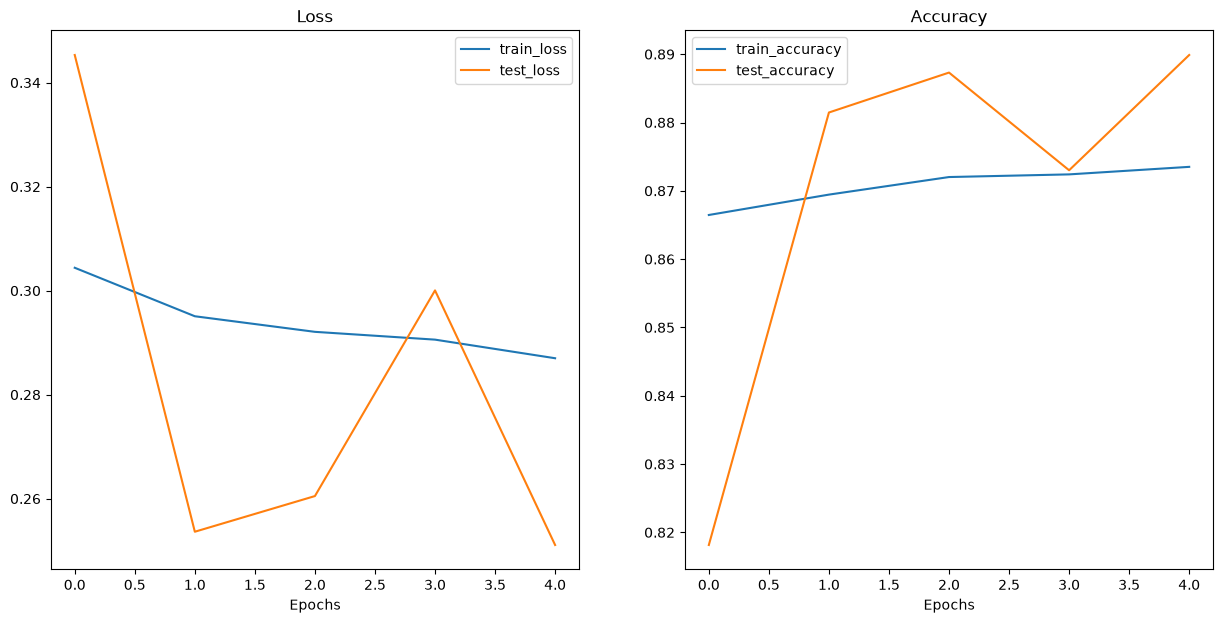

In [72]:
plot_loss_curves(distilbert_results)

In [ ]:
def pred_and_store(
    texts: List[str],
    labels: List[int],
    model: torch.nn.Module,
    tokenizer,
    max_length: int = 256,
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
) -> List[Dict]:

    # Create an empty list to store prediction dictionaries
    pred_list = []

    # Prepare model for inference
    model.to(device)
    model.eval()

    # Loop through text samples
    for text, label in tqdm(zip(texts, labels), total=len(texts)):

        # Create empty dictionary for this prediction
        pred_dict = {}

        # Store original text and true label
        pred_dict["text"] = text
        pred_dict["true_label"] = label

        # Start prediction timer
        start_time = timer()

        # Tokenize text
        inputs = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt"
        )

        # Move inputs to target device
        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        # Perform inference
        with torch.inference_mode():

            outputs = model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )

            # Get raw logits
            pred_logits = outputs.logits

            # Convert logits to probabilities
            pred_probs = torch.softmax(pred_logits, dim=1)

            # Get predicted class
            pred_label = torch.argmax(pred_probs, dim=1)

            # Get probability of predicted class
            pred_prob = pred_probs.max(dim=1).values

        # Store prediction information
        pred_dict["pred_prob"] = round(
            pred_prob.item(),
            4
        )

        pred_dict["pred_label"] = pred_label.item()

        # End timer
        end_time = timer()

        pred_dict["time_for_pred"] = round(
            end_time - start_time,
            4
        )

        # Check whether prediction is correct
        pred_dict["correct"] = (
            pred_label.item() == label
        )

        # Add prediction dictionary to list
        pred_list.append(pred_dict)

    return pred_list

In [76]:
predictions = pred_and_store(
    texts=test_dataset["Review Text"].fillna("").astype(str).tolist(),
    labels=test_dataset["Recommended IND"].tolist(),
    model=model,
    tokenizer=tokenizer,
    max_length=256,
    device=device
)

100%|██████████| 4529/4529 [00:38<00:00, 118.59it/s]


In [80]:
bert_test_pred_df = pd.DataFrame(predictions)
bert_test_pred_df.head()

,text,true_label,pred_prob,pred_label,time_for_pred,correct
0,I haven't worn it yet. i tried it on when i go...,1,0.9959,1,0.0657,True
1,"Really nice thick fabric, yet lays really nice...",1,0.9995,1,0.0695,True
2,"This dress is stunning - the cut, the color (m...",1,0.9928,1,0.0476,True
3,I spend a lot of time on the retailer website....,1,0.8161,1,0.0790,True
4,I wanted to love this dress so much but it jus...,0,0.6545,1,0.0098,False


In [81]:
# Find the average time per prediction 
bert_average_time_per_pred = round(bert_test_pred_df.time_for_pred.mean(), 4)
print(f"Bert average time per prediction: {bert_average_time_per_pred} seconds")

Bert average time per prediction: 0.0083 seconds
